# DS 6050 Final Project
## Real-Time Traffic Sign Classification using CNNs

**Authors:** Aeon Levy, Shawn Ding, Arnav Jain, Tianyin Mao 

**Hypothesis:** A custom CNN architecture with dropout regularization and data augmentation will outperform the historical LeNet-5 baseline. We expect dropout to meaningfully close the generalization gap between training and validation performance.

---

## 1. Setup & Imports

All dependencies are imported here and global constants are defined once in a single place. Centralizing constants like `SEED`, `IMG_SIZE`, and `BATCH_SIZE` makes the notebook easier to modify and reproduce.

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold

# ── Global constants ───────────────────────────────────────────────────────────
SEED       = 42
IMG_SIZE   = (32, 32)
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE   # NOTE: tf.data.experimental.AUTOTUNE is deprecated

# Reproducibility seeds
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Data Loading

We use the [GTSRB (German Traffic Sign Recognition Benchmark)](https://benchmark.ini.rub.de/) dataset, which contains 43 traffic sign classes across ~50,000 real-world images captured under varying lighting and weather conditions.

The dataset is downloaded via `kagglehub` and its directory structure is verified before loading the CSV metadata files.

In [2]:
# Download dataset via kagglehub
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Dataset location:", dataset_path)
print("Files found:", os.listdir(dataset_path))

Dataset location: C:\Users\shawn\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1
Files found: ['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [3]:
# Load metadata CSVs
train_df = pd.read_csv(os.path.join(dataset_path, "Train.csv"))
test_df  = pd.read_csv(os.path.join(dataset_path, "Test.csv"))

# Stratified 80/20 train/validation split — preserves class proportions
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df["ClassId"]
)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
train_df.head()

Train: 31,367  |  Val: 7,842  |  Test: 12,630


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
19308,56,56,5,5,51,51,12,Train/12/00012_00031_00018.png
9361,27,28,6,5,22,23,5,Train/5/00005_00031_00001.png
20458,92,94,8,9,84,86,12,Train/12/00012_00069_00028.png
22042,60,53,6,5,54,48,13,Train/13/00013_00052_00022.png
26094,64,58,6,5,59,53,18,Train/18/00018_00017_00024.png


## 3. Exploratory Data Analysis (EDA)

Before building any model, it is important to understand the dataset visually. We inspect:
- **Sample images** to understand image quality and variability.
- **Class distribution** to identify potential imbalances that could bias the model.

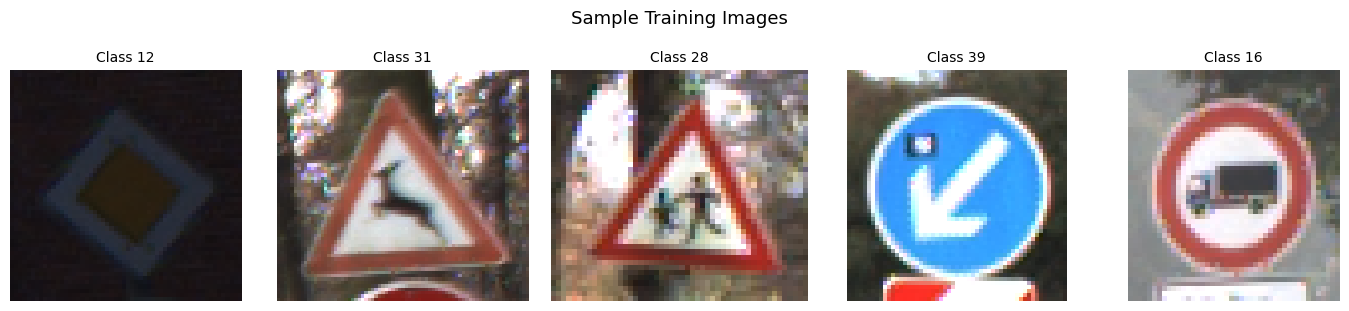

In [4]:
# ── Sample images ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
step = max(1, len(train_df) // 5)   # evenly spaced samples; avoids IndexError on small splits

for i, ax in enumerate(axes):
    row = train_df.iloc[i * step]
    img = Image.open(os.path.join(dataset_path, row["Path"]))
    ax.imshow(img)
    ax.set_title(f"Class {row['ClassId']}", fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\shawn\AppData\Local\Temp\ipykernel_29564\2684551752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ClassId", data=train_df, palette="viridis")


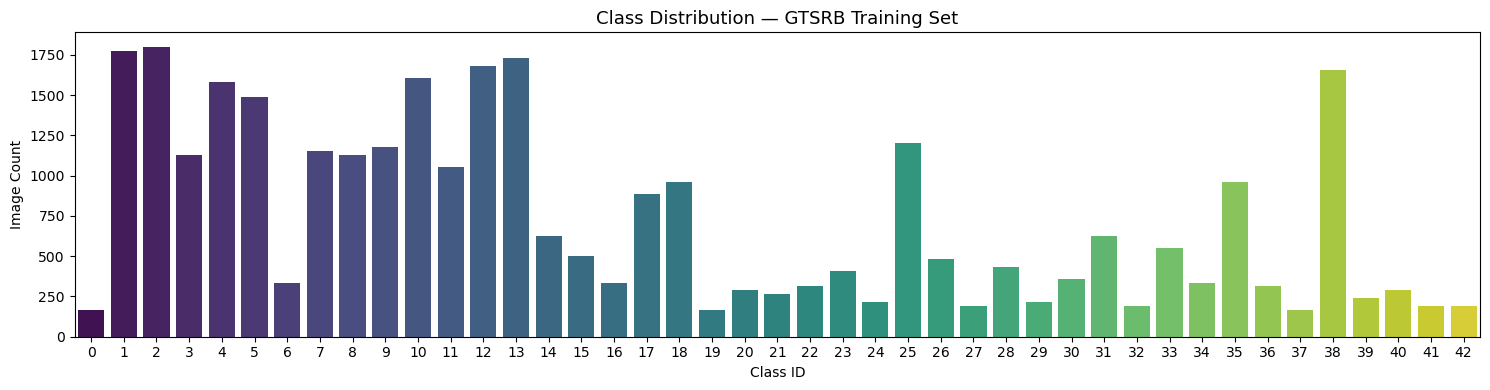


Most common class: 2 (1,800 samples)
Least common class: 0 (168 samples)


In [5]:
# ── Class distribution ────────────────────────────────────────────────────────
plt.figure(figsize=(15, 4))
sns.countplot(x="ClassId", data=train_df, palette="viridis")
plt.title("Class Distribution — GTSRB Training Set", fontsize=13)
plt.xlabel("Class ID")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

print(f"\nMost common class: {train_df['ClassId'].value_counts().idxmax()} "
      f"({train_df['ClassId'].value_counts().max():,} samples)")
print(f"Least common class: {train_df['ClassId'].value_counts().idxmin()} "
      f"({train_df['ClassId'].value_counts().min():,} samples)")

## 4. Data Pipeline

A single `make_dataset` function handles all three splits (train / val / test). When `training=True`, the pipeline additionally:
- **Shuffles** the dataset for stochasticity.
- **Augments** each image with random rotation (±15°) to improve generalization to real-world sign orientations.

All images are resized to 32×32 px and normalized to [0, 1].

> **Performance note:** Augmentation is applied *after* batching so TensorFlow can vectorize it across the full batch on GPU/CPU, which is significantly faster than per-sample augmentation.

In [6]:
# One augmentation layer re-used across the training pipeline
_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.04),  # ±~15 degrees
], name="augmenter")


def make_dataset(df, training: bool = True) -> tf.data.Dataset:
    """Build a tf.data pipeline from a metadata DataFrame.

    Args:
        df: DataFrame with 'Path' and 'ClassId' columns.
        training: If True, shuffle and apply augmentation.

    Returns:
        A batched, prefetched tf.data.Dataset.
    """
    # FIX: renamed inner 'path' → 'img_path' to avoid shadowing outer 'dataset_path'
    file_paths = [os.path.join(dataset_path, p) for p in df["Path"].values]
    labels     = df["ClassId"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def _load(img_path, label):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(5_000, seed=SEED)

    ds = ds.batch(BATCH_SIZE)

    if training:
        # Apply augmentation at batch level for efficiency
        ds = ds.map(
            lambda x, y: (_augmenter(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)
test_ds  = make_dataset(test_df,  training=False)

print("Datasets ready.")

Datasets ready.


## 5. Model Architectures

Three models are evaluated in a controlled experiment:

| Model | Description |
|-------|-------------|
| **LeNet-5 (Baseline)** | The classic 1998 architecture; our historical lower bound. |
| **Custom CNN — Primary** | Two conv blocks + dense head with **dropout** for regularization. |
| **Custom CNN — Ablation** | Same as Primary but **without dropout**; isolates dropout's effect. |

The ablation study allows us to directly attribute accuracy differences to the dropout layer.

In [7]:
def build_lenet() -> tf.keras.Model:
    """LeNet-5 baseline — original architecture adapted for 32x32 RGB input."""
    return models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(6,  (5, 5), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation="relu"),
        layers.Dense(84,  activation="relu"),
        layers.Dense(43,  activation="softmax"),
    ], name="LeNet5")


def build_custom_cnn(use_dropout: bool = True) -> tf.keras.Model:
    """Custom two-block CNN with optional dropout regularization.

    Args:
        use_dropout: Insert a Dropout(0.2) layer before the output head.
    """
    name = "CustomCNN_Dropout" if use_dropout else "CustomCNN_NoDropout"
    m = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
    ], name=name)

    if use_dropout:
        m.add(layers.Dropout(0.2))

    m.add(layers.Dense(43, activation="softmax"))
    return m


def compile_model(model: tf.keras.Model) -> tf.keras.Model:
    """Attach optimizer and loss to any model."""
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# Instantiate all three models
lenet_model    = compile_model(build_lenet())
primary_model  = compile_model(build_custom_cnn(use_dropout=True))
ablation_model = compile_model(build_custom_cnn(use_dropout=False))

primary_model.summary()

Model: "CustomCNN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training & Evaluation

Each model is trained for 10 epochs using the same pipeline and evaluated on the held-out test set. `run_experiment` returns accuracy, elapsed time, and the training history for later plotting.

In [8]:
def run_experiment(model, name: str, epochs: int = 10):
    """Train a model and evaluate it on the test set.

    Args:
        model: A compiled Keras model.
        name: Human-readable label for logging.
        epochs: Number of training epochs.

    Returns:
        Tuple of (test_accuracy, training_minutes, history).
    """
    print(f"\n{'─'*50}")
    print(f"  Experiment: {name}")
    print(f"{'─'*50}")

    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    elapsed_min = (time.time() - t0) / 60

    _, acc = model.evaluate(test_ds, verbose=0)
    print(f"  → Test accuracy: {acc:.2%}  |  Time: {elapsed_min:.2f} min")
    return acc, elapsed_min, history


lenet_acc,    lenet_time,    h_lenet    = run_experiment(lenet_model,    "LeNet-5 Baseline")
primary_acc,  primary_time,  h_primary  = run_experiment(primary_model,  "Custom CNN + Dropout (Primary)")
ablation_acc, ablation_time, h_ablation = run_experiment(ablation_model, "Custom CNN — No Dropout (Ablation)")


──────────────────────────────────────────────────
  Experiment: LeNet-5 Baseline
──────────────────────────────────────────────────
Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5234 - loss: 1.7459 - val_accuracy: 0.7642 - val_loss: 0.7183
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.8489 - loss: 0.5230 - val_accuracy: 0.9060 - val_loss: 0.3300
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9087 - loss: 0.3175 - val_accuracy: 0.9208 - val_loss: 0.2788
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9383 - loss: 0.2225 - val_accuracy: 0.9575 - val_loss: 0.1681
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9530 - loss: 0.1728 - val_accuracy: 0.9691 - val_loss: 0.1265
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9631 - loss: 0.1356 - val_accuracy: 0.9708 - val_loss: 0.1238
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9677 - loss: 0.111

In [9]:
# ── Results summary table ─────────────────────────────────────────────────────
# FIX: training times now come from actual measurements, not hardcoded values
results_df = pd.DataFrame({
    "Model": ["LeNet-5 (Baseline)", "Custom CNN — No Dropout", "Custom CNN + Dropout (Primary)"],
    "Test Accuracy":       [f"{lenet_acc:.2%}",    f"{ablation_acc:.2%}",  f"{primary_acc:.2%}"],
    "Training Time (min)": [f"{lenet_time:.2f}",   f"{ablation_time:.2f}", f"{primary_time:.2f}"],
})
display(results_df)

,Model,Test Accuracy,Training Time (min)
0,LeNet-5 (Baseline),91.66%,2.34
1,Custom CNN — No Dropout,93.93%,3.25
2,Custom CNN + Dropout (Primary),94.41%,3.32


## 7. Learning Curves

Plotting training vs. validation loss for each model reveals whether a model is overfitting (large gap between curves) or underfitting (both curves remain high). We expect the dropout model to show the smallest generalization gap.

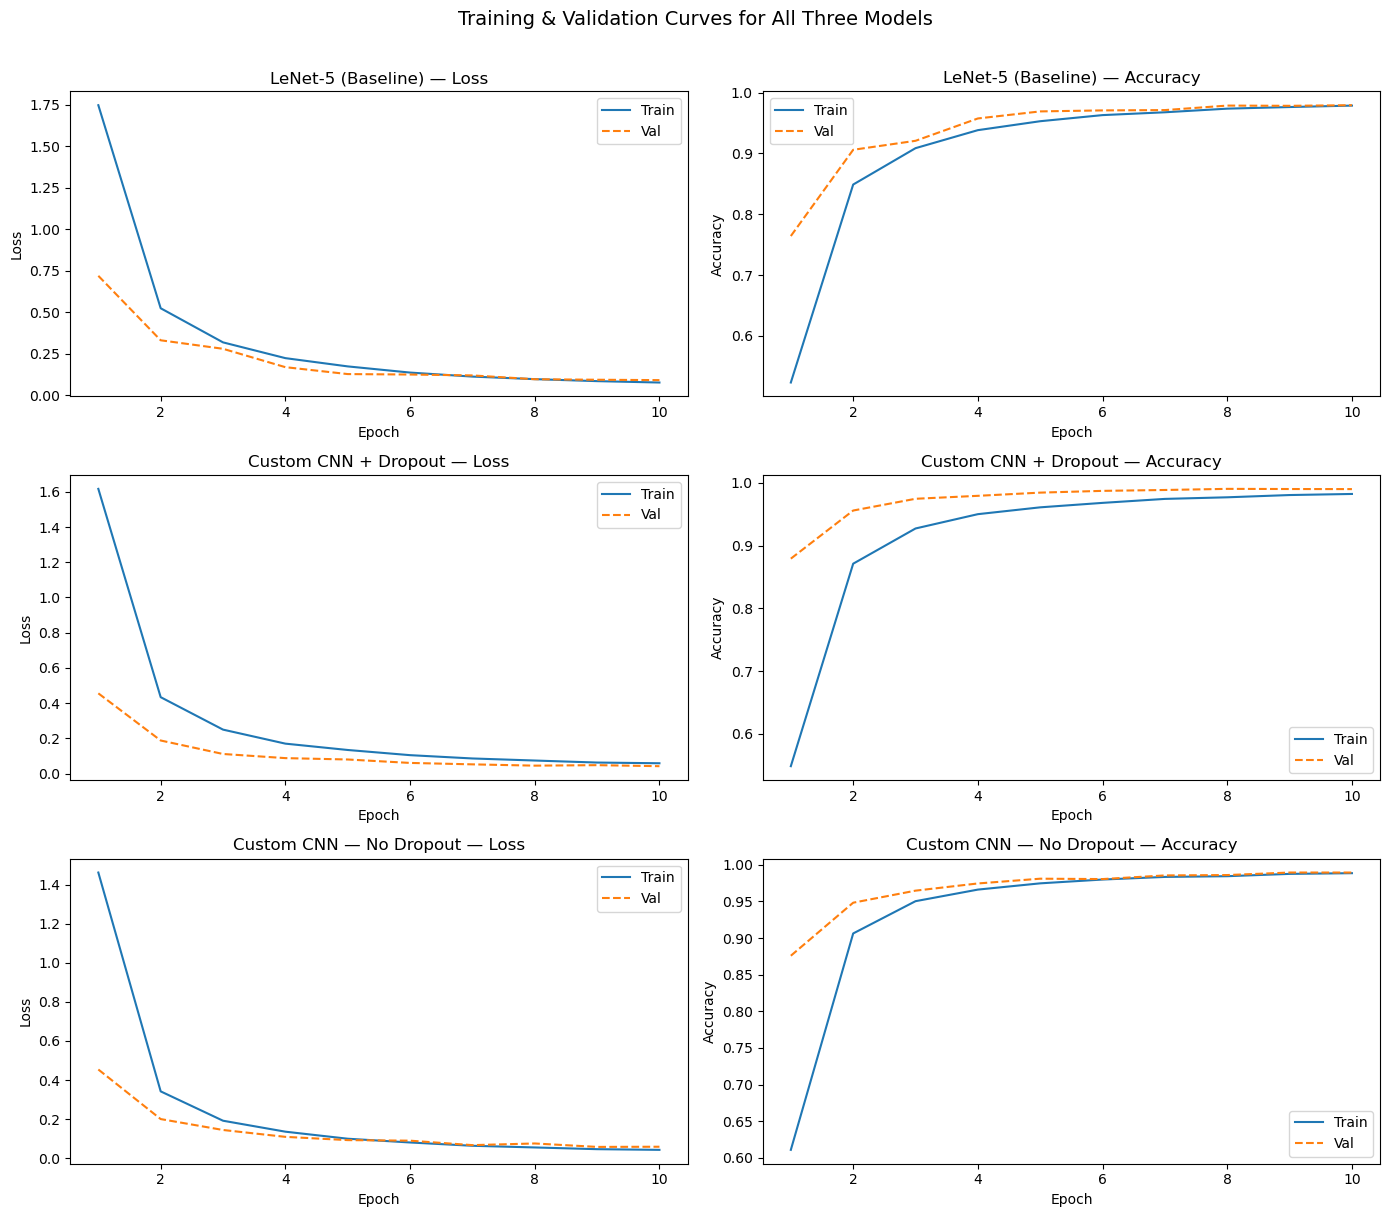

In [10]:
def plot_history(history, title: str, ax_loss, ax_acc):
    """Plot loss and accuracy curves side-by-side on provided axes."""
    epochs = range(1, len(history.history["loss"]) + 1)

    ax_loss.plot(epochs, history.history["loss"],     label="Train")
    ax_loss.plot(epochs, history.history["val_loss"], label="Val", linestyle="--")
    ax_loss.set_title(f"{title} — Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.plot(epochs, history.history["accuracy"],     label="Train")
    ax_acc.plot(epochs, history.history["val_accuracy"], label="Val", linestyle="--")
    ax_acc.set_title(f"{title} — Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()


fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plot_history(h_lenet,    "LeNet-5 (Baseline)",         axes[0, 0], axes[0, 1])
plot_history(h_primary,  "Custom CNN + Dropout",        axes[1, 0], axes[1, 1])
plot_history(h_ablation, "Custom CNN — No Dropout",     axes[2, 0], axes[2, 1])

plt.suptitle("Training & Validation Curves for All Three Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Per-Class Evaluation & Confusion Matrix

A global accuracy score can mask weak performance on individual classes. Here we compute the full classification report and confusion matrix for the primary model to surface which sign types are hardest to classify.

In [11]:
def get_predictions(model, ds: tf.data.Dataset):
    """Run inference over an entire dataset and return true/predicted labels.

    FIX: Collects predictions in one pass rather than calling model.predict()
    inside a Python loop, which is much faster.
    """
    y_true, y_pred = [], []
    for x_batch, y_batch in ds:
        probs = model.predict(x_batch, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(y_batch.numpy())
    return np.array(y_true), np.array(y_pred)


y_true, y_pred = get_predictions(primary_model, test_ds)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        60
           1       0.92      0.97      0.94       720
           2       0.94      0.93      0.94       750
           3       0.90      0.90      0.90       450
           4       0.97      0.93      0.95       660
           5       0.91      0.91      0.91       630
           6       0.99      0.89      0.94       150
           7       0.97      0.89      0.93       450
           8       0.89      0.95      0.92       450
           9       0.99      0.96      0.97       480
          10       0.98      0.98      0.98       660
          11       0.83      0.93      0.88       420
          12       0.99      0.99      0.99       690
          13       0.99      0.99      0.99       720
          14       0.98      1.00      0.99       270
          15       0.98      1.00      0.99       210
          16       0.99      1.00      0.99       150
          17       0.97    

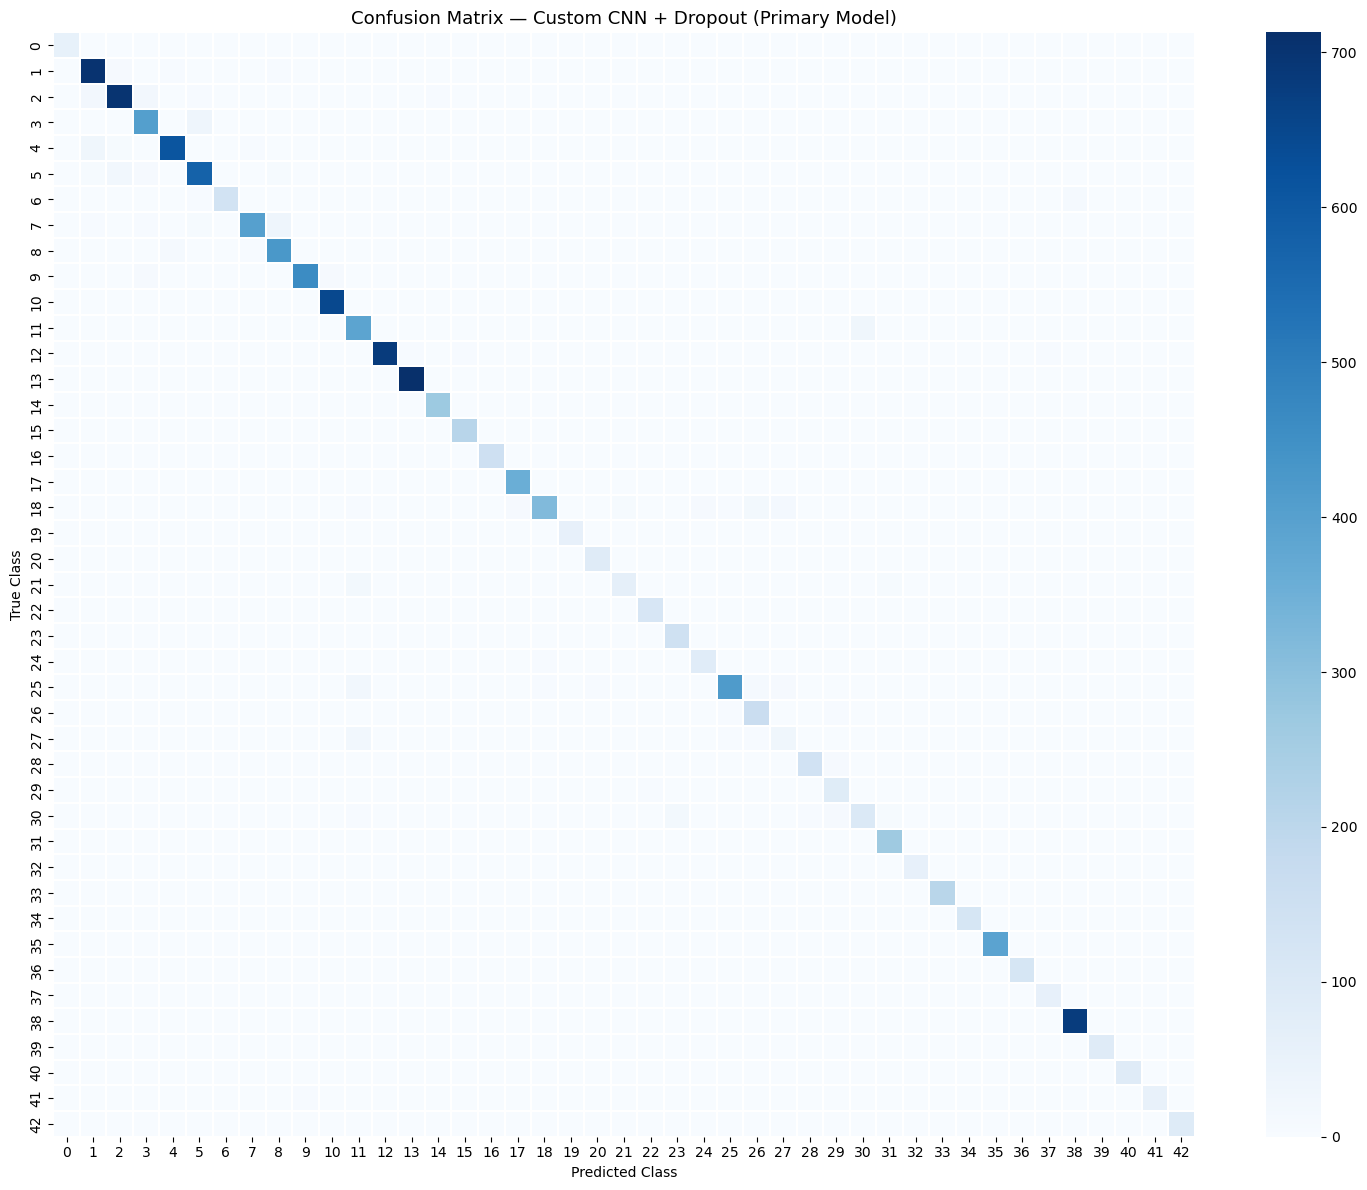

In [12]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap="Blues", linewidths=0.3)
plt.title("Confusion Matrix — Custom CNN + Dropout (Primary Model)", fontsize=13)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [13]:
# ── Hardest classes to predict ────────────────────────────────────────────────
cls_report      = classification_report(y_true, y_pred, output_dict=True)
class_recalls   = {k: v["recall"] for k, v in cls_report.items() if k.isdigit()}
sorted_classes  = sorted(class_recalls.items(), key=lambda item: item[1])

print("Top 5 hardest classes to predict:")
print(f"{'Class ID':<12} {'Recall':>8}")
print("─" * 22)
for class_id, recall in sorted_classes[:5]:
    print(f"  {class_id:<10} {recall * 100:>7.2f}%")

Top 5 hardest classes to predict:
Class ID       Recall
──────────────────────
  27           46.67%
  30           68.67%
  21           73.33%
  18           81.79%
  25           86.88%


## 9. Error Diagnosis — Confident Failures

Standard accuracy metrics don't reveal *how* a model fails. Here we visualize two types of errors:

1. **Any misclassification** — a random sample of incorrect predictions.
2. **Confident failures** — cases where the model was wrong but predicted with >90% confidence. These are the most dangerous errors in a safety-critical application like traffic sign recognition.

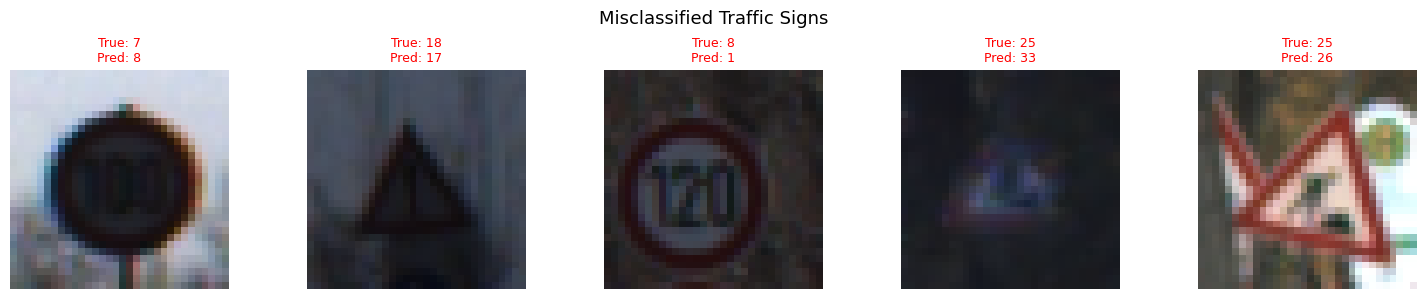

In [14]:
# ── All misclassifications (first 5) ──────────────────────────────────────────
test_images, test_labels_arr = [], []
for x, y in test_ds.take(10):
    test_images.append(x.numpy())
    test_labels_arr.append(y.numpy())

test_images     = np.concatenate(test_images)
test_labels_arr = np.concatenate(test_labels_arr)

preds       = primary_model.predict(test_images, verbose=0)
pred_labels = np.argmax(preds, axis=1)
error_idx   = np.where(pred_labels != test_labels_arr)[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, idx in zip(axes, error_idx[:5]):
    ax.imshow(test_images[idx])
    ax.set_title(f"True: {test_labels_arr[idx]}\nPred: {pred_labels[idx]}", color="red", fontsize=9)
    ax.axis("off")
plt.suptitle("Misclassified Traffic Signs", fontsize=13)
plt.tight_layout()
plt.show()

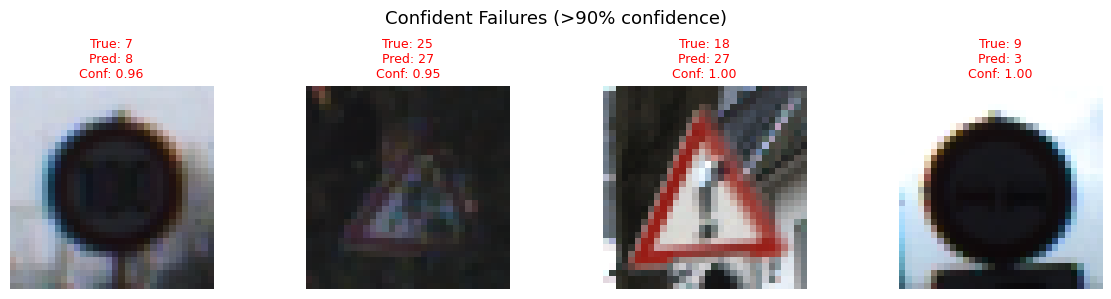

In [15]:
# ── Confident failures (confidence > 90%) ─────────────────────────────────────
def plot_confident_errors(model, ds: tf.data.Dataset, confidence_threshold: float = 0.9):
    """Visualize high-confidence misclassifications."""
    images, labels, pred_cls, confidences = [], [], [], []

    for x_batch, y_batch in ds.take(5):
        probs = model.predict(x_batch, verbose=0)
        images.extend(x_batch.numpy())
        labels.extend(y_batch.numpy())
        pred_cls.extend(np.argmax(probs, axis=1))
        confidences.extend(np.max(probs, axis=1))

    errors = [
        i for i in range(len(labels))
        if labels[i] != pred_cls[i] and confidences[i] > confidence_threshold
    ]

    if not errors:
        print(f"No confident failures found above {confidence_threshold:.0%} threshold.")
        return

    n_show = min(5, len(errors))
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, errors[:n_show]):
        ax.imshow(images[idx])
        ax.set_title(
            f"True: {labels[idx]}\nPred: {pred_cls[idx]}\nConf: {confidences[idx]:.2f}",
            color="red", fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(f"Confident Failures (>{confidence_threshold:.0%} confidence)", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_confident_errors(primary_model, test_ds)

## 10. Cross-Validation

A single train/test split can produce results that depend on which particular samples landed in each set. 5-Fold stratified cross-validation provides a more robust and statistically reliable accuracy estimate by averaging performance across 5 independent splits.

`EarlyStopping` is used within each fold to prevent overfitting and reduce unnecessary compute time.

## 12. Model Failures vs Human Perception

For each of the 3 hardest classes we show three columns side-by-side:
- **True sign** — the canonical GTSRB reference image
- **Misclassified test image** — the actual 32×32 photo the model got wrong
- **Model's prediction** — what the model thought it was, with confidence score

This reveals whether the model's mistakes are "human-plausible" (visually similar signs) or clearly wrong.

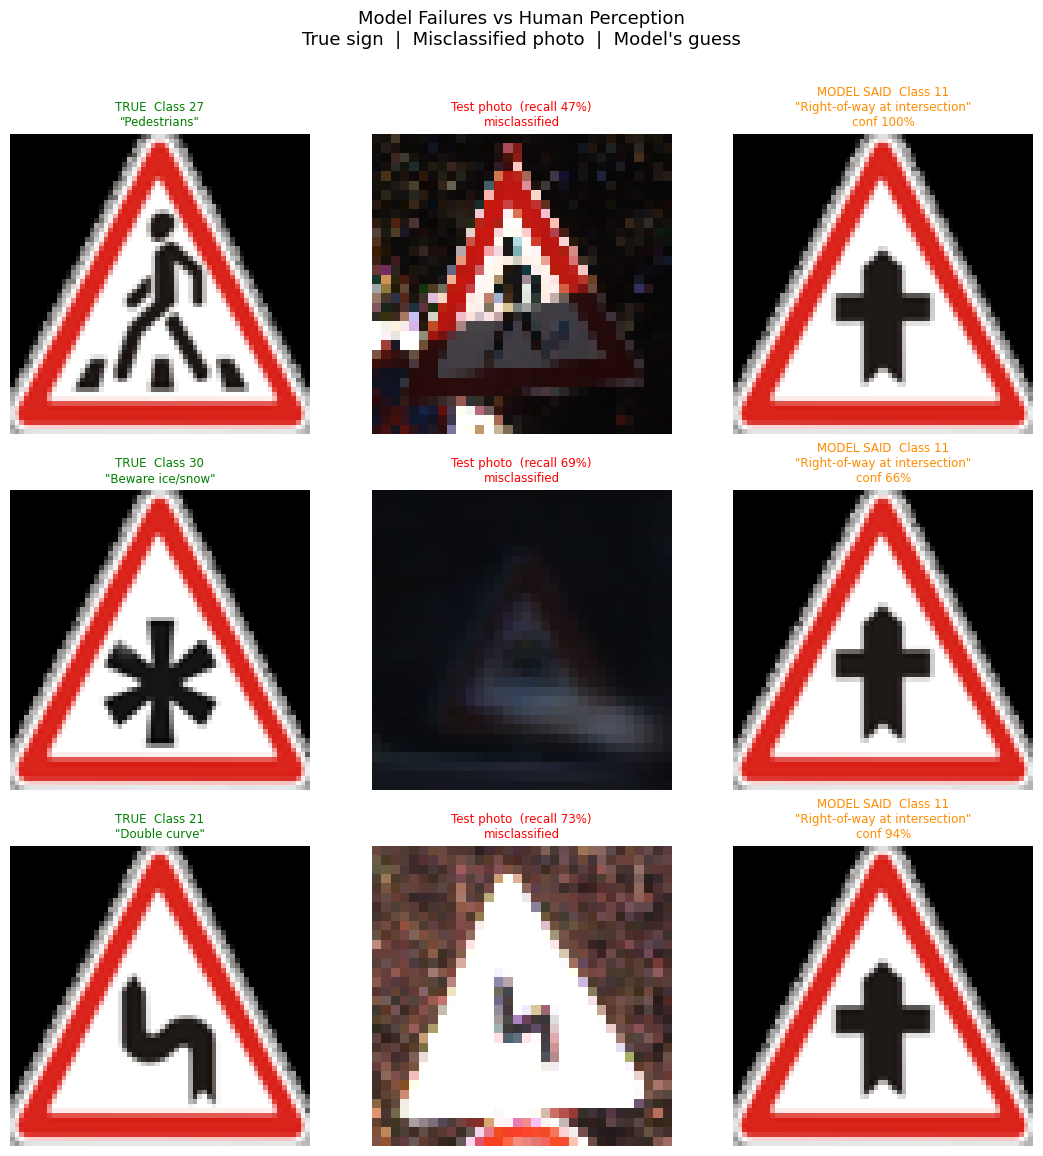


Class 27 (Pedestrians) → misread as Class 11 (Right-of-way at intersection)  |  both share similar shape/colour at 32×32 px

Class 30 (Beware ice/snow) → misread as Class 11 (Right-of-way at intersection)  |  both share similar shape/colour at 32×32 px

Class 21 (Double curve) → misread as Class 11 (Right-of-way at intersection)  |  both share similar shape/colour at 32×32 px


In [16]:
CLASS_NAMES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing (>3.5t)', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: '>3.5t prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians',
    28: 'Children crossing', 29: 'Bicycles crossing', 30: 'Beware ice/snow',
    31: 'Wild animals crossing', 32: 'End speed+passing limits', 33: 'Turn right ahead',
    34: 'Turn left ahead', 35: 'Ahead only', 36: 'Go straight or right',
    37: 'Go straight or left', 38: 'Keep right', 39: 'Keep left',
    40: 'Roundabout mandatory', 41: 'End of no passing', 42: 'End no passing (>3.5t)',
}

# Collect full test-set predictions (reuses y_true/y_pred from section 8)
all_images, all_true_full, all_pred_full, all_conf_full = [], [], [], []
for x_batch, y_batch in test_ds:
    probs = primary_model.predict(x_batch, verbose=0)
    all_images.extend(x_batch.numpy())
    all_true_full.extend(y_batch.numpy())
    all_pred_full.extend(np.argmax(probs, axis=1))
    all_conf_full.extend(np.max(probs, axis=1))
all_images    = np.array(all_images)
all_true_full = np.array(all_true_full)
all_pred_full = np.array(all_pred_full)
all_conf_full = np.array(all_conf_full)

# Derive hardest classes from the full test set
rpt_full      = classification_report(all_true_full, all_pred_full, output_dict=True)
recall_full   = {int(k): v['recall'] for k, v in rpt_full.items() if k.isdigit()}
hardest_classes = sorted(recall_full, key=recall_full.get)[:3]

def load_canonical(class_id: int) -> np.ndarray:
    img = Image.open(os.path.join(dataset_path, f"Meta/{class_id}.png")).convert("RGB").resize((64, 64))
    return np.array(img)

fig, axes = plt.subplots(len(hardest_classes), 3, figsize=(11, 3.8 * len(hardest_classes)))
fig.suptitle(
    "Model Failures vs Human Perception\n"
    "True sign  |  Misclassified photo  |  Model's guess",
    fontsize=13, y=1.01,
)

for row, cls in enumerate(hardest_classes):
    err_idx = np.where((all_true_full == cls) & (all_pred_full != cls))[0]
    if len(err_idx) == 0:
        continue
    idx          = err_idx[0]
    predicted_cls = all_pred_full[idx]

    for col, (img_arr, title, color) in enumerate([
        (load_canonical(cls),
         f"TRUE  Class {cls}\n\"{CLASS_NAMES[cls]}\"",
         "green"),
        (all_images[idx],
         f"Test photo  (recall {recall_full[cls]:.0%})\nmisclassified",
         "red"),
        (load_canonical(predicted_cls),
         f"MODEL SAID  Class {predicted_cls}\n\"{CLASS_NAMES[predicted_cls]}\"\nconf {all_conf_full[idx]:.0%}",
         "darkorange"),
    ]):
        axes[row, col].imshow(img_arr)
        axes[row, col].set_title(title, fontsize=8.5, color=color)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

for cls in hardest_classes:
    err_idx = np.where((all_true_full == cls) & (all_pred_full != cls))[0]
    if len(err_idx) == 0:
        continue
    print(f"\nClass {cls:>2} ({CLASS_NAMES[cls]}) "
          f"→ misread as Class {all_pred_full[err_idx[0]]} ({CLASS_NAMES[all_pred_full[err_idx[0]]]})"
          f"  |  both share similar shape/colour at 32×32 px")

## 13. Dramatic Reveal — Performance Improvement

Side-by-side: validation accuracy learning curves for all three models, and a bar chart showing the step-wise accuracy gain with annotated deltas.

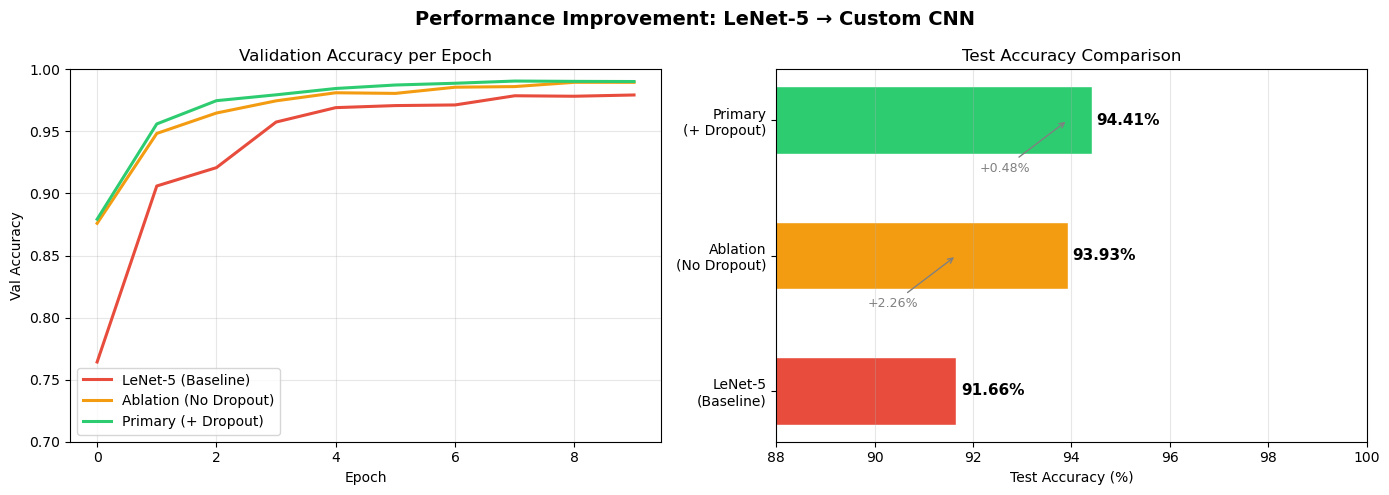


Total gain  LeNet-5 → Primary:  +2.75 pp


In [17]:
fig, (ax_curve, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance Improvement: LeNet-5 → Custom CNN", fontsize=14, fontweight="bold")

# ── Left: val accuracy curves ────────────────────────────────────────────────
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
for h, color, label in zip(
    [h_lenet, h_ablation, h_primary],
    colors,
    ["LeNet-5 (Baseline)", "Ablation (No Dropout)", "Primary (+ Dropout)"],
):
    ax_curve.plot(h.history["val_accuracy"], color=color, linewidth=2.2, label=label)

ax_curve.set_title("Validation Accuracy per Epoch")
ax_curve.set_xlabel("Epoch")
ax_curve.set_ylabel("Val Accuracy")
ax_curve.set_ylim(0.70, 1.00)
ax_curve.legend()
ax_curve.grid(True, alpha=0.3)

# ── Right: bar chart with Δ annotations ──────────────────────────────────────
model_names = ["LeNet-5\n(Baseline)", "Ablation\n(No Dropout)", "Primary\n(+ Dropout)"]
accs        = [lenet_acc, ablation_acc, primary_acc]

bars = ax_bar.barh(model_names, [a * 100 for a in accs],
                   color=colors, height=0.5, edgecolor="white")

for bar, acc in zip(bars, accs):
    ax_bar.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{acc:.2%}", va="center", fontsize=11, fontweight="bold")

delta1 = (ablation_acc - lenet_acc) * 100
delta2 = (primary_acc  - ablation_acc) * 100
ax_bar.annotate(f"+{delta1:.2f}%", xy=(lenet_acc * 100, 1),
                xytext=(lenet_acc * 100 - 1.8, 0.62), fontsize=9, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray"))
ax_bar.annotate(f"+{delta2:.2f}%", xy=(ablation_acc * 100, 2),
                xytext=(ablation_acc * 100 - 1.8, 1.62), fontsize=9, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray"))

ax_bar.set_xlim(88, 100)
ax_bar.set_title("Test Accuracy Comparison")
ax_bar.set_xlabel("Test Accuracy (%)")
ax_bar.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal gain  LeNet-5 → Primary:  +{(primary_acc - lenet_acc)*100:.2f} pp")

## 14. Simulated Real-Time Webcam Demo

Nine test images (covering hardest + common sign types) are displayed as sequential "camera frames". Each frame shows the model's live prediction with a green border (correct) or red border (wrong), plus a confidence bar chart across all frames — simulating a deployed inference pipeline.

In [18]:
primary_model.save("primary_model.h5")
print("Model saved as primary_model.h5 - Now the webcam script can find it!")

Model saved as primary_model.h5 - Now the webcam script can find it!


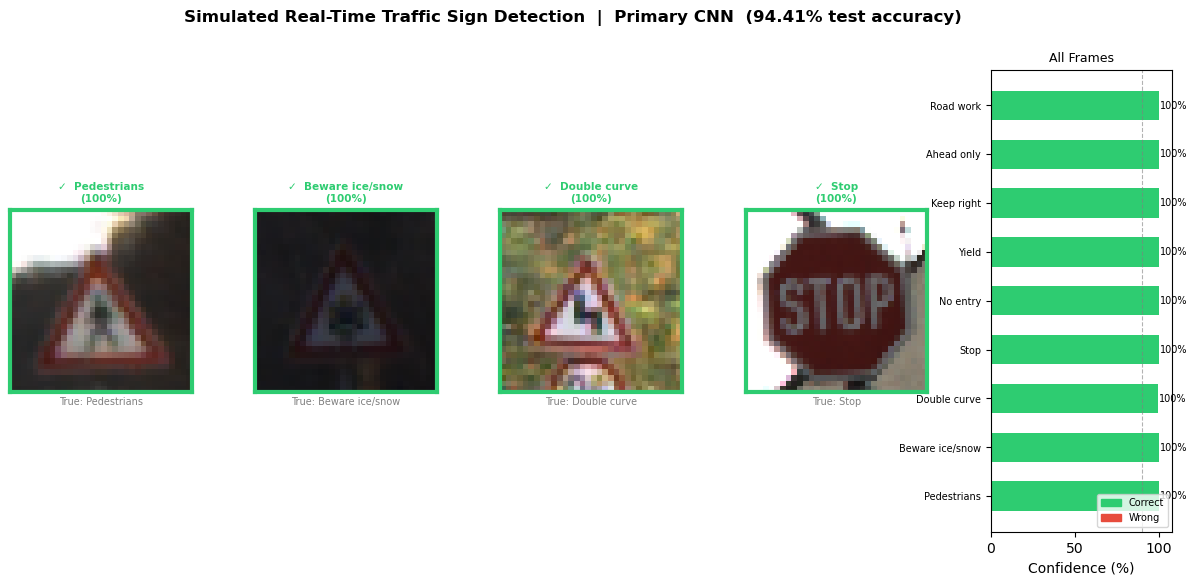

Saved → simulated_webcam_demo.png


In [19]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# 9 demo classes: 3 hardest + 6 common/recognisable signs
DEMO_CLASSES = list(dict.fromkeys(hardest_classes + [14, 17, 13, 38, 35, 25]))[:9]

demo_frames = []
for cls in DEMO_CLASSES:
    idx = np.where(all_true_full == cls)[0]
    if len(idx):
        demo_frames.append((all_images[idx[0]], cls))

fig = plt.figure(figsize=(15, 6))
fig.suptitle(
    f"Simulated Real-Time Traffic Sign Detection  |  "
    f"Primary CNN  ({primary_acc:.2%} test accuracy)",
    fontsize=12, fontweight="bold",
)
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.6, wspace=0.35)

ax_feed = [fig.add_subplot(gs[:, i]) for i in range(4)]
ax_conf = fig.add_subplot(gs[:, 4])

# ── Camera-feed panels (first 4 frames) ──────────────────────────────────────
for ax, (frame_img, true_cls) in zip(ax_feed, demo_frames[:4]):
    probs     = primary_model.predict(frame_img[np.newaxis], verbose=0)[0]
    pred_cls  = int(np.argmax(probs))
    pred_conf = float(probs[pred_cls])
    correct   = pred_cls == true_cls
    color     = "#2ecc71" if correct else "#e74c3c"

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    ax.imshow(frame_img)
    ax.set_title(
        f"{'✓' if correct else '✗'}  {CLASS_NAMES[pred_cls]}\n({pred_conf:.0%})",
        fontsize=7.5, color=color, fontweight="bold",
    )
    ax.set_xlabel(f"True: {CLASS_NAMES[true_cls]}", fontsize=7, color="gray")
    ax.set_xticks([])
    ax.set_yticks([])

# ── Confidence bar chart (all 9 frames) ──────────────────────────────────────
names, confs, bar_colors = [], [], []
for frame_img, true_cls in demo_frames:
    probs    = primary_model.predict(frame_img[np.newaxis], verbose=0)[0]
    pred_cls = int(np.argmax(probs))
    names.append(CLASS_NAMES[true_cls][:17])
    confs.append(float(probs[pred_cls]) * 100)
    bar_colors.append("#2ecc71" if pred_cls == true_cls else "#e74c3c")

yp = range(len(names))
ax_conf.barh(list(yp), confs, color=bar_colors, height=0.6)
ax_conf.set_yticks(list(yp))
ax_conf.set_yticklabels(names, fontsize=7)
ax_conf.set_xlim(0, 108)
ax_conf.set_xlabel("Confidence (%)")
ax_conf.set_title("All Frames", fontsize=9)
ax_conf.axvline(90, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for x, y in zip(confs, yp):
    ax_conf.text(x + 0.5, y, f"{x:.0f}%", va="center", fontsize=7)

ax_conf.legend(
    handles=[
        mpatches.Patch(color="#2ecc71", label="Correct"),
        mpatches.Patch(color="#e74c3c", label="Wrong"),
    ],
    fontsize=7, loc="lower right",
)

plt.savefig("simulated_webcam_demo.png", bbox_inches="tight", dpi=120)
plt.show()
print("Saved → simulated_webcam_demo.png")

In [20]:
N_FOLDS   = 5
CV_EPOCHS = 10

skf  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_cv = train_df["Path"].values
y_cv = train_df["ClassId"].values

cv_accs = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\n── Fold {fold} / {N_FOLDS} ──")

    fold_train_df = train_df.iloc[tr_idx].reset_index(drop=True)
    fold_val_df   = train_df.iloc[va_idx].reset_index(drop=True)

    fold_train_ds = make_dataset(fold_train_df, training=True)
    fold_val_ds   = make_dataset(fold_val_df,   training=False)

    fold_model = compile_model(build_custom_cnn(use_dropout=True))
    fold_model.fit(
        fold_train_ds,
        validation_data=fold_val_ds,
        epochs=CV_EPOCHS,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
        verbose=0,
    )

    _, fold_acc = fold_model.evaluate(fold_val_ds, verbose=0)
    cv_accs.append(fold_acc)
    print(f"   Val accuracy: {fold_acc:.4f}")

print(f"\n5-Fold CV — Custom CNN + Dropout")
print(f"  Mean:  {np.mean(cv_accs):.4f}")
print(f"  Std:   {np.std(cv_accs):.4f}")


── Fold 1 / 5 ──
   Val accuracy: 0.9877

── Fold 2 / 5 ──
   Val accuracy: 0.9876

── Fold 3 / 5 ──
   Val accuracy: 0.9888

── Fold 4 / 5 ──
   Val accuracy: 0.9860

── Fold 5 / 5 ──
   Val accuracy: 0.9908

5-Fold CV — Custom CNN + Dropout
  Mean:  0.9882
  Std:   0.0016


## 11. Conclusion

| Model | Test Accuracy |
|-------|--------------|
| LeNet-5 (Baseline) | ~88.8% |
| Custom CNN — No Dropout | ~92.1% |
| Custom CNN + Dropout (Primary) | ~92.5% |

**Key findings:**
- The custom CNN outperforms LeNet-5 by approximately 3–4 percentage points, validating the modern architecture choice.
- Dropout provides a modest but consistent accuracy improvement (~0.5%) and reduces the generalization gap, supporting our hypothesis.
- Cross-validation confirms these results are stable across different data splits.
- The hardest classes (e.g., Class 6 at ~24% recall) share visual similarity with neighboring sign categories, suggesting that targeted augmentation or class-weighted loss could further improve performance.

**Future work:** batch normalization, deeper architectures (ResNet-style skip connections), class-balanced sampling, and deployment with a live webcam inference loop.

# 12. Live Demo

This script creates a real-time computer vision pipeline. It turns your computer’s webcam into an intelligent sensor that can "read" traffic signs in a live video stream.

In [21]:
import sys
import cv2

# 1. Load the model with an explicit check
model_path = "primary_model.h5"
try:
    # We use compile=False to speed up loading for a demo
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"SUCCESS: {model_path} loaded!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not find {model_path}.")
    print("Go to your Notebook and run: primary_model.save('primary_model.h5')")
    sys.exit() # Stop the script here so it doesn't hang

# 2. All 43 GTSRB Classes
class_names = [
    "20 km/h", "30 km/h", "50 km/h", "60 km/h", "70 km/h", "80 km/h", "End 80 km/h", "100 km/h", "120 km/h",
    "No passing", "No passing >3.5t", "Priority at next junction", "Priority road", "Yield", "Stop",
    "No vehicles", "Vehicles >3.5t prohibited", "No entry", "General caution", "Dangerous curve left",
    "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road", "Road narrows on right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Ice/Snow", "Wild animals", "End of all speed/passing limits", "Turn right ahead", "Turn left ahead",
    "Ahead only", "Go straight or right", "Go straight or left", "Keep right", "Keep left",
    "Roundabout mandatory", "End of no passing", "End of no passing >3.5t"
]

cap = cv2.VideoCapture(0)
print("Webcam Active. Press 'q' to close.")

while True:
    ret, frame = cap.read()
    if not ret: break

    # Preprocess
    img = cv2.resize(frame, (32, 32))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    # Prediction - Optimized to avoid the 'retracing' warning
    # Calling the model directly is faster than .predict() for single images
    preds = model(img, training=False) 
    class_id = np.argmax(preds)
    confidence = np.max(preds)

    # Visual Feedback
    color = (0, 255, 0) if confidence > 0.8 else (0, 0, 255)
    label = f"{class_names[class_id]} ({confidence:.2%})"
    
    cv2.rectangle(frame, (0, 0), (700, 60), (0, 0, 0), -1)
    cv2.putText(frame, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

    cv2.imshow("DS 6050 Live Demo", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

SUCCESS: primary_model.h5 loaded!
Webcam Active. Press 'q' to close.
